## Predict Product Prices

### Week 7 Day 2

Selecting our model and evaluating the base model against the task.

Keep in mind: our base model has 8 billion params, quantized down to 4 bits
Compared with GPT-4o at TRILLIONS of params!

# IMPORTANT please read me!!

When you run the pip installs below, you may get an error from pip complaining about an incompatible version of fsspec.

You should ignore that error! The version of fsspec is the right version, needed by HuggingFace.

If you ask ChatGPT, it will encourage you to pip install a more recent version of fsspec. But that would be problematic; HuggingFace will fail to load the dataset later with an obscure error about file systems.

So please run the pip installs as they appear below, and look the other way if you get an error!


In [26]:
# pip installs - ignore the error message!

!pip install -q datasets requests torch peft bitsandbytes transformers trl accelerate sentencepiece tiktoken matplotlib

In [27]:
# imports

import os
import re
import math
from tqdm import tqdm
from google.colab import userdata
from huggingface_hub import login
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments, set_seed
from peft import LoraConfig, PeftModel
from datasets import load_dataset, Dataset, DatasetDict
from datetime import datetime
import matplotlib.pyplot as plt

In [28]:
# Tokenizers

LLAMA_3_1 = "meta-llama/Meta-Llama-3.1-8B"
QWEN_2_5 = "Qwen/Qwen2.5-7B"
GEMMA_2 = "google/gemma-2-9b"
PHI_3 = "microsoft/Phi-3-medium-4k-instruct"

# Constants

BASE_MODEL = LLAMA_3_1
HF_USER = "christseng898" # your HF name here!
DATASET_NAME = f"{HF_USER}/lite-data"

MAX_SEQUENCE_LENGTH = 182
QUANT_4_BIT = True

# Used for writing to output in color

GREEN = "\033[92m"
YELLOW = "\033[93m"
RED = "\033[91m"
RESET = "\033[0m"
COLOR_MAP = {"red":RED, "orange": YELLOW, "green": GREEN}

%matplotlib inline

### Log in to HuggingFace

If you don't already have a HuggingFace account, visit https://huggingface.co to sign up and create a token.

Then select the Secrets for this Notebook by clicking on the key icon in the left, and add a new secret called `HF_TOKEN` with the value as your token.

In [29]:
# Log in to HuggingFace

hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

In [30]:
def investigate_tokenizer(model_name):
  print("Investigating tokenizer for", model_name)
  tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
  for number in [0, 1, 10, 100, 999, 1000]:
    tokens = tokenizer.encode(str(number), add_special_tokens=False)
    print(f"The tokens for {number}: {tokens}")

In [32]:
# Now we will try this with each model: LLAMA_3_1, QWEN_2_5, GEMMA_2, PHI_3
print("LLAMA_3_1 investigation tokenizer ...")
investigate_tokenizer(LLAMA_3_1)

print("\nQWEN_2_5 investigation tokenizer ...")
investigate_tokenizer(QWEN_2_5)

print("\nGEMMA_2 investigation tokenizer ...")
investigate_tokenizer(GEMMA_2)

print("\nPHI_3 investigation tokenizer ...")
investigate_tokenizer(PHI_3)

LLAMA_3_1 investigation tokenizer ...
Investigating tokenizer for meta-llama/Meta-Llama-3.1-8B
The tokens for 0: [15]
The tokens for 1: [16]
The tokens for 10: [605]
The tokens for 100: [1041]
The tokens for 999: [5500]
The tokens for 1000: [1041, 15]

QWEN_2_5 investigation tokenizer ...
Investigating tokenizer for Qwen/Qwen2.5-7B
The tokens for 0: [15]
The tokens for 1: [16]
The tokens for 10: [16, 15]
The tokens for 100: [16, 15, 15]
The tokens for 999: [24, 24, 24]
The tokens for 1000: [16, 15, 15, 15]

GEMMA_2 investigation tokenizer ...
Investigating tokenizer for google/gemma-2-9b
The tokens for 0: [235276]
The tokens for 1: [235274]
The tokens for 10: [235274, 235276]
The tokens for 100: [235274, 235276, 235276]
The tokens for 999: [235315, 235315, 235315]
The tokens for 1000: [235274, 235276, 235276, 235276]

PHI_3 investigation tokenizer ...
Investigating tokenizer for microsoft/Phi-3-medium-4k-instruct
The tokens for 0: [29871, 29900]
The tokens for 1: [29871, 29896]
The tok

# Load our data

We uploaded it to Hugging Face, so it's easy to retrieve it now

In [ ]:
dataset = load_dataset(DATASET_NAME)
train = dataset['train']
test = dataset['test']

README.md:   0%|          | 0.00/413 [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/45.7M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/1.35M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3000 [00:00<?, ? examples/s]

In [ ]:
test[0]

{'text': 'How much does this cost to the nearest dollar?\n\nLenovo ThinkVision 23.8 Full HD WLED LCD Monitor - 16 9 - Raven Black\nPower through your day on the ThinkVision Its FHD In-Plane Switching bezels helping you enhance efficiency. The TÜV Rheinland Eye Comfort certified ThinkVision is ideal for professionals as it minimizes eye fatigue and strain. Transfer or receive data with ease using varied options to connect other peripherals. This monitor is thoughtfully designed to keep your desk space organized and provide ergonomic benefits to users who spend long hours at work. Package Dimensions 18.592 cms (L) x 43.103 cms (W) x 18.592 cms (H) Package Quantity 1 Country Of Origin China Standing screen display size 23.8 Inches, Screen Resolution 192\n\nPrice is $',
 'price': 249.0}

# Prepare our Base Llama Model for evaluation

Load our base model with 4 bit quantization and try out 1 example

In [ ]:
## pick the right quantization

if QUANT_4_BIT:
  quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
  )
else:
  quant_config = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_compute_dtype=torch.bfloat16
  )

In [ ]:
# Load the Tokenizer and the Model

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=quant_config,
    device_map="auto",
)
base_model.generation_config.pad_token_id = tokenizer.pad_token_id

print(f"Memory footprint: {base_model.get_memory_footprint() / 1e9:.1f} GB")

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

...

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

Memory footprint: 5.6 GB


In [ ]:
def extract_price(s):
    if "Price is $" in s:
      contents = s.split("Price is $")[1]
      contents = contents.replace(',','').replace('$','')
      match = re.search(r"[-+]?\d*\.\d+|\d+", contents)
      return float(match.group()) if match else 0
    return 0

In [ ]:
extract_price("Price is $999 blah blah so cheap")

999.0

In [ ]:
def model_predict(prompt):
    set_seed(42)
    inputs = tokenizer.encode(prompt, return_tensors="pt").to("cuda")
    attention_mask = torch.ones(inputs.shape, device="cuda")
    outputs = base_model.generate(inputs, max_new_tokens=4, attention_mask=attention_mask, num_return_sequences=1)
    response = tokenizer.decode(outputs[0])
    return extract_price(response)

In [ ]:
model_predict(test[0]['text'])

299.0

# Evaluation!

Trying out our base Llama 3.1 model against the Test dataset

In [ ]:
class Tester:

    def __init__(self, predictor, data, title=None, size=250, print_detail=False):
        self.predictor = predictor
        self.data = data
        self.title = title or predictor.__name__.replace("_", " ").title()
        self.size = size
        self.print_detail = print_detail  # ✅ 預設 False
        self.guesses = []
        self.truths = []
        self.errors = []
        self.sles = []
        self.colors = []

    def color_for(self, error, truth):
        if error<40 or error/truth < 0.2:
            return "green"
        elif error<80 or error/truth < 0.4:
            return "orange"
        else:
            return "red"

    def run_datapoint(self, i):
        datapoint = self.data[i]
        guess = self.predictor(datapoint["text"])
        truth = datapoint["price"]
        error = abs(guess - truth)
        log_error = math.log(truth+1) - math.log(guess+1)
        sle = log_error ** 2
        color = self.color_for(error, truth)
        title = datapoint["text"].split("\n\n")[1][:20] + "..."
        self.guesses.append(guess)
        self.truths.append(truth)
        self.errors.append(error)
        self.sles.append(sle)
        self.colors.append(color)
        # ✅ 根據 print_detail 判斷輸出詳細或統計
        if self.print_detail:
            print(f"{COLOR_MAP[color]}{i+1}: Guess: ${guess:,.2f} Truth: ${truth:,.2f} Error: ${error:,.2f} SLE: {sle:,.2f} Item: {title}{RESET}")
        elif (i + 1) % (self.size // 10) == 0:
            percent = int((i + 1) / self.size * 100)
            hits_so_far = sum(1 for c in self.colors[:i+1] if c == "green")
            hit_rate = hits_so_far / (i + 1) * 100
            print(f"Process status: {percent}% | Hits Rate so far: {hit_rate:.1f}%")

    def chart(self, title):
        max_error = max(self.errors)
        plt.figure(figsize=(12, 8))
        max_val = max(max(self.truths), max(self.guesses))
        plt.plot([0, max_val], [0, max_val], color='deepskyblue', lw=2, alpha=0.6)
        plt.scatter(self.truths, self.guesses, s=3, c=self.colors)
        plt.xlabel('Ground Truth')
        plt.ylabel('Model Estimate')
        plt.xlim(0, max_val)
        plt.ylim(0, max_val)
        plt.title(title)
        plt.show()

    def report(self):
        average_error = sum(self.errors) / self.size
        rmsle = math.sqrt(sum(self.sles) / self.size)
        hits = sum(1 for color in self.colors if color=="green")
        title = f"{self.title} Error=${average_error:,.2f} RMSLE={rmsle:,.2f} Hits={hits/self.size*100:.1f}%"
        self.chart(title)

    def run(self):
        self.error = 0
        for i in range(self.size):
            self.run_datapoint(i)
        self.report()

    @classmethod
    def test(cls, function, data):
        cls(function, data).run()

Process status: 10% | Hits Rate so far: 80.0%
Process status: 20% | Hits Rate so far: 80.0%
Process status: 30% | Hits Rate so far: 76.0%
Process status: 40% | Hits Rate so far: 76.0%
Process status: 50% | Hits Rate so far: 75.2%
Process status: 60% | Hits Rate so far: 73.3%
Process status: 70% | Hits Rate so far: 73.1%
Process status: 80% | Hits Rate so far: 72.5%
Process status: 90% | Hits Rate so far: 73.3%
Process status: 100% | Hits Rate so far: 71.6%


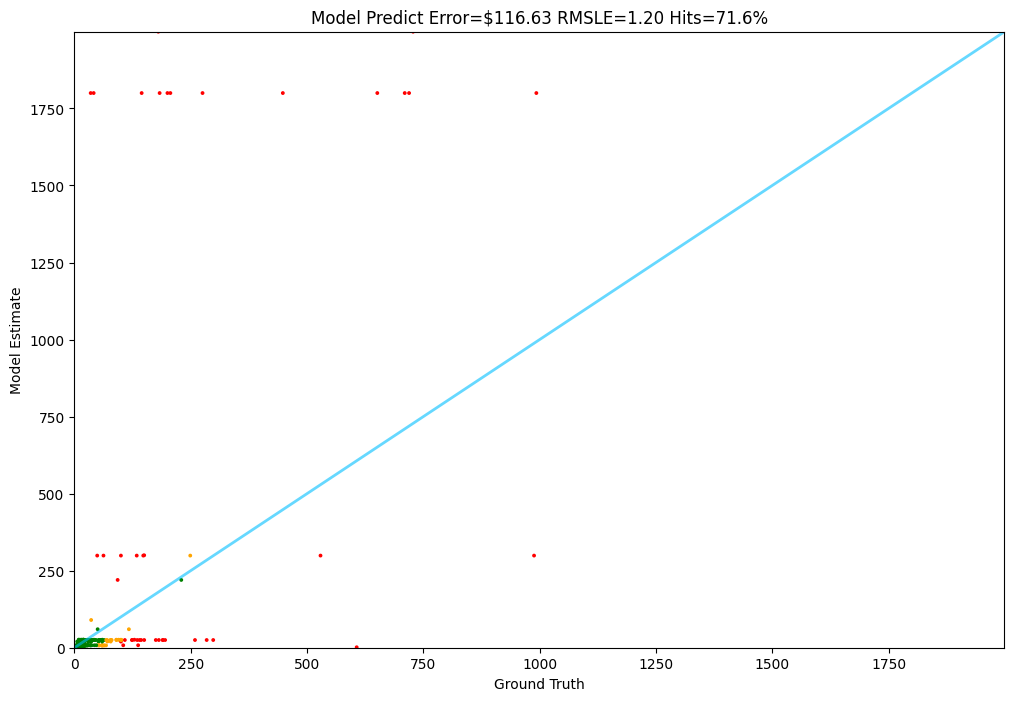

In [ ]:
Tester.test(model_predict, test)